In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
from My_Solvers.pde_solvers import fdm
from My_Solvers.haar import create_haar, create_haar_2d

In [2]:
def f(x):
    #return np.where(x < 0.25, 1, 2)
    return np.cos(x)**np.exp(np.cos(40*x**2))
    #return x**2
Num = 6
N = 2**Num
X = np.linspace(1/(2*N), 1 - 1/(2*N), N)
Y = f(X)

A, H, C = create_haar(Y)

First, plot the haar transform and the given function and compare. 

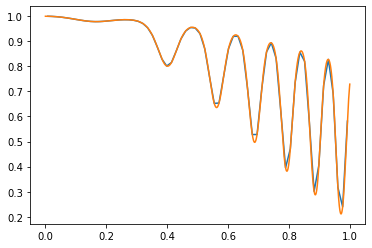

In [3]:
Z = np.zeros(H.shape[1])
for k in range(H.shape[0]):
    Z += H[k,:]
Z += A[-1,:]
plt.plot(X, Z)
plt.plot(np.linspace(0,1, 2**(16)), f(np.linspace(0,1, 2**(16))))

Now add noise and use Haars to de--noise. But first plot the noisy signal.

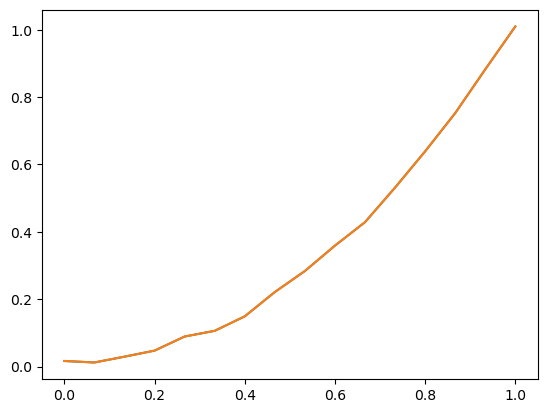

In [689]:
Yn = Y + np.random.normal(0, .01, size = Y.shape)
An, Hn, Cn = create_haar(Yn)
Zn = np.zeros(Hn.shape[1])
Xn = np.linspace(0,1,Zn.size)
for k in range(Hn.shape[0]):
    Zn += Hn[k,:]
Zn += An[-1,:]
plt.plot(Xn, Zn)
plt.plot(Xn, Yn)

C is the matrix of coefficients. So find where those are "big" and delete the corresponding values from H.

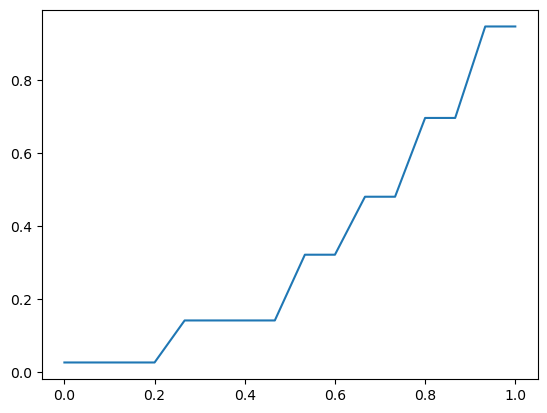

In [690]:
th = .1 * np.max(np.abs(Cn))
Hdn = np.where(np.abs(Cn) >= th, Hn, 0)
#Hdn = H * Cdn

Zdn = np.zeros(Hdn.shape[1])
Xn = np.linspace(0,1,Zn.size)
for k in range(Hn.shape[0]):
    Zdn += Hdn[k,:]
Zdn += An[-1,:]
plt.plot(Xn, Zdn)
#plt.plot(Xn, Yn)
#plt.plot(X, Y)

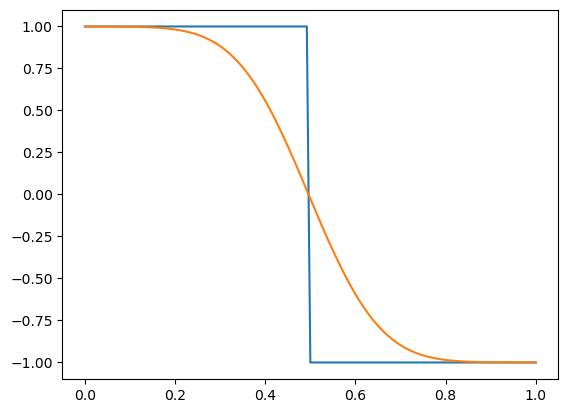

In [55]:
def haar(x):
    return np.where(x < .5, 1, -1)
def haar2(x):
    return np.sqrt(2)*haar(2*x)
T1, X1, U1 = fdm(haar, 1, 1/2**Num, 1/128, 1, lbc = [0,1,0], rbc = [0,1,0])

plt.plot(X1, haar(X1))

plt.plot(X1,U1[-1,])

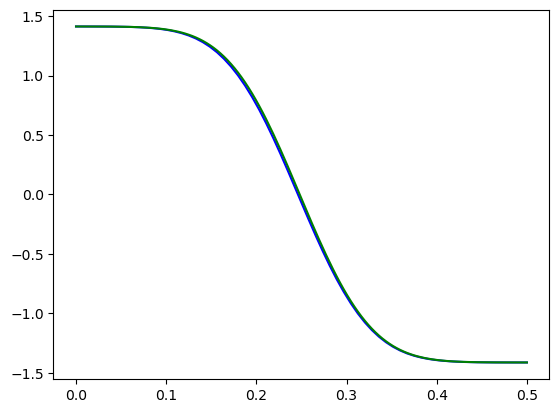

In [57]:
T2, X2, U2 = fdm(haar2, 1, 1/2**Num, .25/128, 1/2, lbc = [0,1,0], rbc = [0,1,0])
plt.plot(X2,U2[-1,], color = 'blue')
plt.plot(np.linspace(0,.5, U1[-1,].size), np.sqrt(2)*U1[-1,], color = 'green')
#plt.plot(X2, haar2(X2))

In [5]:
np.linspace(0,1,9)

array([0.   , 0.125, 0.25 , 0.375, 0.5  , 0.625, 0.75 , 0.875, 1.   ])

In [7]:
N = 2**3
np.linspace(1/(2*N), 1 - 1/(2*N), N)

array([0.0625, 0.1875, 0.3125, 0.4375, 0.5625, 0.6875, 0.8125, 0.9375])

In [38]:
Num = 2
N = 2**Num
x = np.linspace(1/(2*N), 1 - 1/(2*N), N)
y = np.linspace(1/(2*N), 1 - 1/(2*N), N)
X, Y = np.meshgrid(x, y)

def g(x, y):
    return -x + y

Z = g(X, Y)
print(Z)

[[ 0.   -0.25 -0.5  -0.75]
 [ 0.25  0.   -0.25 -0.5 ]
 [ 0.5   0.25  0.   -0.25]
 [ 0.75  0.5   0.25  0.  ]]


In [39]:
A = create_haar_2d(Z)